# Homework 3B: Homography

<small>v1.0</small>

**DUE DATE**: February 26, 11:59pm Pacific via Canvas

* You can save a copy of this document in your own Drive and work on it in your own Colab
* You can add comments, multiple cells, etc. Just make sure to explain what you did so that we can give you partial credit if necessary
* Make sure to rely only on allowed Python libraries. Each problem will state what's allowed
* When you're done, go to "Runtime > Restart session and run all" to make sure your notebook runs correctly from top to bottom
* **You need to submit two things: an .ipynb and .pdf file.** Go to "File > Download > Download .ipynb" to download the raw Jupyter Notebook file. Then go to "File > Print" and choose "Save as PDF" (or similar). **Make sure the files were produced correctly (sometimes long files get truncated).** We can only grade what you submit. Then upload both files (and the files from HW2A) to the Canvas assignment folder.
* Remember, you are expected to work alone. You can ask questions on Piazza or discuss a solution approach with your peers, but you must not copy their code.
The implementation must be yours. **AI may only be used as outlined in the course's AI-use policy - all AI use must be disclosed below.**

Changelog:
- v1.0: Initial version

# AI-Use Disclosure

**You must complete this section to receive a score.**
If you do not submit an AI-use disclosure, your homework will receive **0 points** until a disclosure is provided. Please reply below.

Was AI used? Yes/No

If **Yes**, briefly describe how you used AI (1--3 sentences). Permitted examples include: conceptual clarification, debugging assistance, generating a plot, or rewriting an explanation.

---

AI was used to debug and explain some parts of code that were confusing. Additionally, AI was used to explain libraries and functions being called. Specifically in part 2, AI was used to explain the different functions being used in the cv2 library and help explain what they were doing to the image.

---

# 0. Intro to OpenCV

Although some parts of this exercise could be done with scikit-image, we will be focusing on a different library this time: [OpenCV](https://opencv.org).

Built to provide a common infrastructure for computer vision applications, OpenCV has become a comprehensive set of both classic and state-of-the-art computer vision (and some machine learning) algorithms.
According to their own documentation, OpenCV has a user community of more than 47,000 people and has been downloaded over seven million times. That's pretty impressive! As an open-source project, it is very easy for researchers, businesses, and government bodies to utilize and modify already available code.

Usually it is a bit of a pain to install, which is probably why Google Colab is providing us with a pre-installed version:

In [ ]:
import cv2
cv2.__version__

You should see version 4.13.0 is installed.

We'll all use the same random seed so it's slightly easier to grade the assignment.

In [ ]:
cv2.setRNGSeed(42)

If you fell in love with the great documentation and consistent API of scikit-image, you're in for a rude awakening. Primarily a C/C++ library, the Python interface to OpenCV is merely a wrapper around the core library. This allows OpenCV to maintain its execution speed, but often compromises usability. A lot.
<br><small>I mean it's a complete dumpster fire. Usually when I write OpenCV code, I need to have a second window open with the documentation (because the API is inconsistent and unintuitive), and a third window with the GitHub repo (because the documentation is wrong). Which is probably why it's still a good business to write books about how to use OpenCV... On that note, you might be interested in [[1](https://github.com/mbeyeler/opencv-python-blueprints),[2](https://github.com/mbeyeler/opencv-machine-learning)], which comes with free GitHub code (also, let me know if you want a copy).</small>

## Getting help with OpenCV

You can always start typing and let Colab autocomplete your code. When a function is typed out, you should see the docstring appear that tells you what arguments the function takes.

However, if you need more details, the best starting point for getting help is the [OpenCV documentation](https://docs.opencv.org/4.13.0) - make sure you're reading the docs for the correct version!!

You will notice that the docs are tailored towards the C++ interface. So this is just your first stop to learn about each function is doing and what arguments it takes. (You may also want to look through the tutorials.) If you can understand what a certain function does in OpenCV, all that is left is converting the syntax from C++ to Python.
For example, [resize](https://docs.opencv.org/4.13.0/da/d54/group__imgproc__transform.html#ga47a974309e9102f5f08231edc7e7529d) explains how to resize an image, but its arguments are `InputArray src`, `OutputArray dst`, `Size dsize` etc. This tells you that the first two arguments are arrays and the third is a scalar. However, in Python the images are just plain NumPy arrays rather than `Array` objects, which leads us to the next point.


## Dealing with Images in OpenCV

For the purpose of this assignment, the most important thing to know is how OpenCV stores images.

So far we have mostly dealt with grayscale images, but you may know that color images are usually stored as RGB images.
The important thing to know is that OpenCV stores them not as RGB, but as BGR images (why?? ask OpenCV's [founder](https://learnopencv.com/why-does-opencv-use-bgr-color-format/)).

<small>If you don't know what I mean, consider a grayscale image with 30 pixel height and 40 pixel width. This would usually be stored as a 2D NumPy array of shape 30x40, usually with values between 0 and 255 (8 bit encoding).
An RGB image of the same dimensions would be stored as a 3D NumPy array of shape 30x40x3. The slice `img[:, :, 0]` would be a 30x40 array whose values (between 0 and 255) represent the amount of red for each pixel, `img[:, :, 1]` has all the green values, and `img[:, :, 2]` has all the blue values.
However, not in OpenCV: `img[:, :, 0]` is the blue channel, `img[:, :, 1]` is the green channel, and `img[:, :, 2]` is the red channel (i.e., the red and blue channels are swapped).</small>

## Dealing with error messages

They're gonna happen, I can guarantee it.

Most often, the error message is cryptic and unrelated to what you're doing. Because every Python call is a wrapper around a C++ function, datatypes are super important.
So whenever you get something along the lines of "wrong format" or "wrong type", make sure your variables have the right datatype and dimensions.

When in doubt, `np.float32(my_variable)` or `np.int32(my_variable)` is your friend.
To check the dimensions of your NumPy array, use `my_array.shape` and `my_array.reshape((dim1, dim2, ..., dimN))`.

# 1. Image Warping (16pts)

In this part we want to apply a perspective projection to [Storke Tower](https://drive.google.com/file/d/1H144iSqUWhH3LKu-89s1hJBPVpyVU7fw/view?usp=sharing) using `cv2.warpProjection`.

The image looks like this:

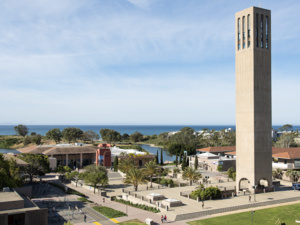

## 1.1 Load the Image

First step is to download the image:

In [ ]:
!pip install gdown
import gdown

In [ ]:
gdown.download("https://drive.google.com/uc?id=1H144iSqUWhH3LKu-89s1hJBPVpyVU7fw", output="storke.jpg", quiet=True)

 Then we can load the image using `cv2.imread`. Let's store the height of the image in variable `h` and the width of the image in variable `w`.

In [ ]:
img = cv2.imread("storke.jpg")
h, w = img.shape[:2]
h, w

Then use `cv2_imshow` (**note:** not `cv2.imshow`) to make sure you loaded the file correctly.

<small>Because of the RGB <=> BGR thing, we won't use Matplotlib to plot the image, but OpenCV's own `imshow` function (which Colab had to patch). </small>

In [ ]:
from google.colab.patches import cv2_imshow

cv2_imshow(img)

## 1.2 Affine Transformations (10pts)

In this section, we will apply a number of affine transformations to the image by writing our own transformation matrices using NumPy arrays.

> **Note**: [`cv2.warpPerspective`](https://docs.opencv.org/4.13.0/da/d54/group__imgproc__transform.html#gaf73673a7e8e18ec6963e3774e6a94b87) should be the only OpenCV function to use in Section 1.2.

### 1.2.1 **TODO:** Apply Translation (4pts)

Write a function that takes as input `tx` and `ty`, which specify by how many pixels the image should be shifted, and returns a projection matrix that can be applied to a 2D image with `cv2.warpPerspective` to shift an image.

> **Hint:** Because OpenCV is written in C++ (we're just using the Python bindings), data types are important. If you create a NumPy array (here and throughout the assignment), make sure to specify `dtype=np.float32` or similar. Otherwise you might get cryptic error messages (and rarely, more specific ones like "Assertion failed, M0.type() == CV_32F").

In [ ]:
import numpy as np

def trans(tx, ty):
  M = np.array([[1, 0, tx], [0, 1, ty], [0, 0, 1]], dtype = np.float32)
  return M

Now use your function to shift the image:

* vertically: 20 pixels down
* horizontally: 50 pixels to the left


In [ ]:
T = trans(-50, 20)

Display the shifted image to make sure you did it right:

In [ ]:
cv2_imshow(cv2.warpPerspective(img, T, (w, h)))

Do you see a black border? Where does that come from (what is the meaning of it)?

---

When shifting the image, output has the same size but the pixels are shifted. The top and left region have no source pixels so no pixels were translated to that area

---

How is the coordinate system oriented here? That is:
- Where is the origin of the coordinate system?
- How does `tx` shift the image? (rows vs. columns, up vs. down, left vs. right)
- How does `ty` shift the image? (rows vs. columns, up vs. down, left vs. right)

---

The origin is at the top left corner of the image. tx shifts along the columns on the horizontal axis. If tx is negative it shifts the image to the left, which is why in our example the black border is created on the right. ty shifts along the rows on the vertical axis. A positive ty shifts it downward, which is why the black border appeared on the top.

---

### 1.2.2 **TODO:** Scale the Image (2pts)

Write a function that takes as input a scale factor `s` and returns a projection matrix that can be applied to a 2D image with `cv2.warpPerspective` to scale an image by factor `s`.

In [ ]:
def scale(s):
  M = np.array([[s, 0, 0], [0, s, 0], [0, 0, 1]], dtype=np.float32)
  return M

Now use your function to scale the image by factor 0.5.

In [ ]:
S = scale(0.5)

In [ ]:
cv2_imshow(cv2.warpPerspective(img, S, (w, h)))

Can you shift the down-scaled Storke tower image so that it appears in the center of the projected image? i.e. something that looks like this:

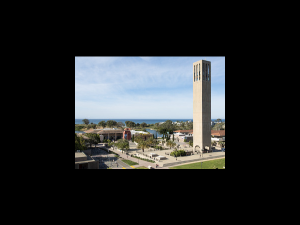

In [ ]:
M = trans(w//4, h//4)
img_scale = cv2.warpPerspective(img, S, (w // 2, h // 2))
cv2_imshow(cv2.warpPerspective(img_scale, M, (w, h)))

### 1.2.3 **TODO:** Apply Rotation (4 pts)

Finally, write a function that takes as input an angle `theta` and returns a projection matrix that can be applied to a 2D image with `cv2.warpPerspective` to rotate an image counter-clockwise by `theta` degrees.

In [ ]:
import math
def rot(theta):
  M = np.array([[math.cos(theta), -math.sin(theta), 0], [math.sin(theta), math.cos(theta), 0], [0, 0, 1]], dtype = np.float32)
  return M

Now use your function to rotate the image counter-clockwise by 45 degrees.

In [ ]:
R = rot(math.radians(-45))
cv2_imshow(cv2.warpPerspective(img, R, (w, h)))

Now take the downscaled image from Section 1.2.2 (scale factor 0.5), rotate it by 45 degrees and shift it to the center of the image, such that the end result looks like this:

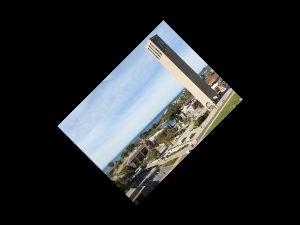

In [ ]:
S = scale(0.5)
R = rot(math.radians(-45))
T1 = trans(-w/2, -h/2)
T2 = trans(w/2, h/2)

mod_matrix = T2 @ R @ S @ T1

modified_image = cv2.warpPerspective(img, mod_matrix, (w, h))
cv2_imshow(modified_image)

## 1.3 Homography (6pts)

Now let's consider the general case, where the projection matrix is given as:

$$H = \begin{bmatrix} a & b & c \\ d & e & f \\ g & h & 1\end{bmatrix}$$

We already know what variables $a$ through $f$ do from lecture, but what are $g$ and $h$ good for?

> **Note**: `cv2.warpPerspective` and `cv2.findHomography` should be the only two OpenCV functions to use in Section 1.3.

### 1.3.1 **TODO:** Variable $g$ (2pts)

What happens when you change $g$? To answer this, you'll want to start from an identity matrix and slowly increase/decrease $g$. How does the image change, and how would you describe this transformation? Show your work.

> **Hint:** You may want to downscale the Storke image first and shift it to the center of the projected image (like we did above). Then it will be a little easier to see what transformation is taking place.

---

g controls the distortion along the horizontal axis. As you change g, it changes how the image is pulled or pushed away from you. As g increases, the corners of the image are pushed away from you but as g decreases, the corners of the image are pulled towards you.

---

In [ ]:
img_homography = cv2.warpPerspective(img, S, (w // 2, h // 2))
img_homography = cv2.warpPerspective(img_scale, M, (w, h))
for g in [-0.005, -0.003, -0.001,0, 0.001, 0.003, 0.005]:
    H = np.array([[1, 0, 0], [0, 1, 0], [g, 0, 1]], dtype = np.float32)
    result = cv2.warpPerspective(img_homography, H, (w, h))
    print(f"g = {g}")
    cv2_imshow(result)

### 1.3.2 **TODO:** Variable $h$ (2pts)

Same question, but for the other variable, $h$?

---

h is similar to g but controls the distortion along the vertical axis. As you increase h, the top of the image is tilted towards you while the bottom is away from you. As you decrease h, the top of the image is tilted away from you while the bottom is tilted towards you.

---

In [ ]:
for h_val in [-0.005, -0.003, -0.001, 0, 0.001, 0.003, 0.005]:
    H = np.array([[1, 0, 0], [0, 1, 0], [0, h_val, 1]], dtype = np.float32)
    result = cv2.warpPerspective(img_homography, H, (w, h))
    print(f"h = {h_val}")
    cv2_imshow(result)

### 1.3.3 **TODO:** Compute Homography Matrix (2pts)

Lastly, we may want the image to look a certain way (e.g., projected onto a ground plane), but we might not know which homography matrix can get us there.

This is where `cv2.findHomography` can be very helpful - it basically lets you specify where a number of points in the source image (`pts_src`) should be projected to in a new, destination image (`pts_dst`).

In the following cell(s), find the homography matrix that:

* shifts the upper left corner of the image `h/2` pixels down and `w/4` pixels to the right
* shifts the upper right corner of the image `h/2` pixels down and `w/4` pixels to the left
* but leaves the lower left & right corners where they are

If you did it right, your resulting image should look like this:

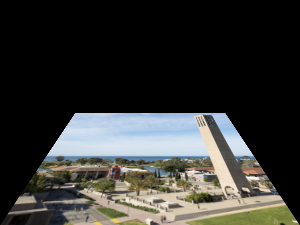

In [ ]:
pts_src = np.array([[0, 0], [w, 0], [0, h], [w, h]], dtype = np.float32) #(upper left, upper right, lower left, lower right)
pts_dst = np.array([[w/4, h/2], [w - w/4, h/2], [0, h], [w, h]], dtype = np.float32)

HH, mask = cv2.findHomography(pts_src, pts_dst)

In [ ]:
cv2_imshow(cv2.warpPerspective(img, HH, (w, h)))

What is the resulting homography matrix? Print it here

In [ ]:
HH

# 2. Feature Matching (8pts)

Now we want to put together everything we have learned about feature extraction, feature matching, and homography estimation in one specific example.



## 2.1 Loading images

First, let's download the images we'll need for this section:

In [ ]:
gdown.download("https://drive.google.com/uc?id=1H3ZZGYzKb91pk6Njun1H8N3_7JwCF6bg", output="box.png", quiet=True)
gdown.download("https://drive.google.com/uc?id=1UHy57_TDUuC4mlA0u3OtbUYHaXCBHnPp", output="box_in_scene.png", quiet=True)

Let's use OpenCV's own load function:

In [ ]:
img_box = cv2.imread('box.png', cv2.IMREAD_GRAYSCALE)

The second argument tells OpenCV whether to load the image color or grayscale.
Because of the RGB <=> BGR thing, we won't use Matplotlib to plot the image, but OpenCV's own `imshow` function (which Colab had to patch):

In [ ]:
cv2_imshow(img_box)

The box is also present in the following scene:

In [ ]:
img_scene = cv2.imread('box_in_scene.png', cv2.IMREAD_GRAYSCALE)
cv2_imshow(img_scene)

Your task will be to extract features from the Bastoncini box in the first image, and use these features to detect the box in the second image.

## 2.2 **TODO:** Detect keypoints using SIFT (1pt)

The first step is feature detection.

Based on the lecture, our first choice might be to use SIFT.
Fortunately, now that the SIFT patent has expired, the functionality has returned to OpenCV!

In the cell below, use SIFT to detect keypoints in both `img_box` and `img_scene`:

In [ ]:
sift_detector = cv2.SIFT.create()

kp_box = sift_detector.detect(img_box)
kp_scene = sift_detector.detect(img_scene)

<small>Hint: You may want to search the [OpenCV 4.13.0 documentation](https://docs.opencv.org/4.13.0) for this. Make sure you're reading the docs of the right version!!</small>

If you did it right, your `kp_box` should contain a list of `Keypoint` objects for `img_box`, each of which contains a number of attributes that inclues the (x,y) location at which the keypoint was found. For example, the first one was found at (x, y) =


In [ ]:
kp_box[0].pt

## 2.3 Visualize the keypoints

Now we can visualize the keypoints of the two images (one image at a time) using `cv2.drawKeypoints` and `cv2_imshow`:

In [ ]:
cv2_imshow(cv2.drawKeypoints(img_box, kp_box, None))

In [ ]:
cv2_imshow(cv2.drawKeypoints(img_scene, kp_scene, None))

## 2.4 **TODO:** Extract SIFT feature descriptors (1 pt)

Now that we have found some keypoints, we want to compute SIFT feature descriptors for them:

In [ ]:
kp_box, desc_box = sift_detector.detectAndCompute(img_box, None)
kp_scene, desc_scene = sift_detector.detectAndCompute(img_scene, None)

Keypoints for which no descriptors could be computed will be removed - that's why the function also returns `kp_box` in addition to `desc_box`.
If you did it right, `desc_box` will contain a list of feature descriptors of length 128; e.g., for the first keypoint:

In [ ]:
kp_box[0].pt, len(desc_box[0])

## 2.5 **TODO:** Perform feature matching using FLANN (1pt)

To perform feature matching, we will use `cv2.FlannBasedMatcher`.
Make sure your matcher returns the 2 best matches.

In [ ]:
matcher = cv2.DescriptorMatcher_create(cv2.DescriptorMatcher_FLANNBASED)
matches = matcher.knnMatch(desc_box, desc_scene, 2)

Finally, visualize the matches using `cv2.drawMatchesKnn`:

In [ ]:
matched_image = cv2.drawMatchesKnn(img_box, kp_box, img_scene, kp_scene, matches, None, flags = cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
cv2_imshow(matched_image)

## 2.6 **TODO:** Implement the ratio test (2 pts)

Each entry of `matches` should now consist of 2 `DMatch` objects: these are the two best matches in `img_scene` for each keypoint in `img_box`:


In [ ]:
matches[0]

Each `DMatch` object has a `distance` field as well as two indices:
- the index of the `img_box` keypoint with which it matches best (`queryIdx`) and
- the index of the `img_scene` keypoint it belongs to (`trainIdx`)  

In [ ]:
kp0_best_match = matches[0][0]
kp0_best_match.queryIdx, kp0_best_match.trainIdx, kp0_best_match.distance

The next step is thus to filter out poor matches with a ratio test.
For each match, compare the distance of the best match with the distance of the second-best match. Store all matches whose best distance is smaller than 80% of the second-best distance in a list:

In [ ]:
# store all the good matches as per Lowe's ratio test.
good = []
for i, j in matches:
  if i.distance < 0.8 * j.distance:
    good.append(i)

print('Number of good matches:', len(good))

## 2.7 **TODO:** Calculate the transformation matrix (3 pts)

Now we want to use the built-in OpenCV functions to find the transformation matrix (also called homography) using RANSAC.

Before we move on, we want to make sure we identified enough matches, otherwise we shouldn't continue:

In [ ]:
MIN_MATCH_COUNT = 10
if len(good) < MIN_MATCH_COUNT:
    raise ValueError(f"Not enough matches are found - {len(good)}/{MIN_MATCH_COUNT}")

Now find the transformation matrix that transforms `box_pts` into `scene_pts` using `cv2.findHomography`. Make sure to use the RANSAC method with `ransacReprojThreshold` 5 (although other values might work as well):

In [ ]:
box_pts = np.float32([kp_box[m.queryIdx].pt for m in good])
scene_pts = np.float32([kp_scene[m.trainIdx].pt for m in good])

H, mask = cv2.findHomography(box_pts, scene_pts, cv2.RANSAC, ransacReprojThreshold = 5)

If you did it right, your `H` should look as close as possible to an affine transformation:

In [ ]:
H

This allows us to visualize the outline of the box in the scene image.

We do this in two steps. First, you need to apply `H` to the corners of the box. `corners_box` is a 4x1x2 matrix that contains the image coordinates of the 4 corners of the box in `img_box`:

In [ ]:
h_box, w_box = img_box.shape[:2]

corners_box = np.array([[0, 0], [w_box, 0], [w_box, h_box], [0, h_box]], dtype = np.float32)
corners_box = corners_box.reshape(4, 1, 2)

Then you need to apply `H` to these coordinates using `cv2.perspectiveTransform`:

In [ ]:
corners_scene = cv2.perspectiveTransform(corners_box, H)

The result can then be visualized with `cv2.polylines` and `cv2_imshow`:

In [ ]:
from copy import deepcopy
cv2_imshow(cv2.polylines(deepcopy(img_scene), [np.int32(corners_scene)], True,
                         255, 3, cv2.LINE_AA))

# 3. Extra Credit: DIY RANSAC (5pts)

Visually inspecting the two images, we know that we can transform the box from the first images to the second image by scaling, rotation, and shifting. In other words, we need to solve for an affine transformation matrix.

In the following more open-ended task, implement your own simple RANSAC algorithm from scratch. It should work as follows:

1. Choose a number of potential inliers (2 points):
   - Pick the smallest number of keypoints from `box_pts`, `scene_pts` needed to fit an affine projection matrix
   - Use function `pred_affine` to predict the transformation matrix for these points
2. Validate the model on all other points (2 points):
   - For all other points, use function `calc_test_err` to calculate the Euclidean distance between predicted and ground-truth coordinates in the scene image
   - Compare each error to `max_err` and use that to count the number of inliers
3. Store the best model (1 points):
   - If the model is better than your previous one, store it.
   - Rinse and repeat for a number of RANSAC iterations `max_iter`
   - Then output the best model

You may find the following functions useful, but feel free to adapt the code or write your own instead:

In [ ]:
def random_partition(n, n_data):
    """Choose `n` random rows of data

    Returns `n` random rows of data (and also the other `len(data)-n` rows)

    Parameters
    ----------
    n : int
        Number of rows to choose at random
    n_data : int
        Number of rows in the data

    Returns
    -------
    idxs1 : list of `n` indices
        `n` rows chosen at random
    idxs2 : list of `len(data)-n` indices
        all the other rows

    """
    all_idxs = np.arange(n_data)
    np.random.shuffle(all_idxs)
    idxs1 = all_idxs[:n]
    idxs2 = all_idxs[n:]
    return idxs1, idxs2

In [ ]:
def pred_affine(box_pts, scene_pts):
    """Predict an affine projection matrix

    Computes the affine transformation that relates 3 pairs of points.

    Parameters
    ----------
    box_pts, scene_pts : 3x2 NumPy array
        3 pairs of keypoints in the box and scene images; each with their own
        (x,y) values

    Returns
    -------
    H : 3x3 NumPy array
        The estimated homography matrix

    """
    H = np.zeros((3, 3))
    H[:2, :] = cv2.getAffineTransform(box_pts, scene_pts)
    H[-1, -1] = 1
    return H

In [ ]:
def calc_test_err(box_pts, scene_pts, H):
    """Calculates the Euclidean distance between each pair of points

    Parameters
    ----------
    box_pts, scene_pts : Nx2 NumPy array
        Keypoints in the box and scene images; each with their own (x,y) values
    H : 3x3 NumPy array
        Homography matrix

    Returns
    -------
    err : Nx1 NumPy array
        The Euclidean distance between the two points for each pair

    """
    pred_scene_pts = cv2.perspectiveTransform(box_pts, H)
    err = np.sqrt(np.sum((pred_scene_pts - scene_pts) ** 2, axis=-1))
    return err

If you choose to use the above functions, you may first want to experiment with them a little to get a better understanding of how they work.

Then, implement RANSAC in the following function:

In [ ]:
def run_affine_ransac(box_pts, scene_pts, max_err, max_iter):
    """Use RANSAC to estimate an affine transformation

    Parameters
    ----------
    box_pts, scene_pts : Nx2 NumPy array
        A number of corresponding (x,y) values
    max_err : float
        Max Euclidean distance above which a match is considered an outlier
    max_iter : int
        Number of RANSAC iterations

    Returns
    -------
    best_H : 3x3 NumPy array
        The best homography matrix
    best_num_inliers : int
        Number of inliers achieved with the best homography matrix
    """
    # For reproducibility, always use the same seed:
    np.random.seed(42)
    # Start at iteration 0, increment until you reach `max_iter`:
    iterations = 0
    # We'll store the best result here, but initialize with 0:
    best_num_inliers = 0
    best_H = None
    # Number of points needed to predict the homography:
    num_pts = 3

    while iterations < max_iter:
        ...
        ...
        ...
        iterations += 1
    return best_H, best_num_inliers

Make sure to choose sensible values for `max_err` and `max_iter`, and run RANSAC:

In [ ]:
H_affine, num_inliers = run_affine_ransac(...)
print('num_inliers:', num_inliers)
print('H:', H_affine)

To verify the result, we can again project the corner points of the box into the scene image and visualize the outline of the box:

In [ ]:
h, w = img_box.shape
corners_box = np.float32([...,
                          ...,
                          ...,
                          ...]).reshape(-1,1,2)
corners_scene = cv2.perspectiveTransform(corners_box, H_affine)
cv2_imshow(cv2.polylines(deepcopy(img_scene), [np.int32(corners_scene)], True,
                         255, 3, cv2.LINE_AA))

If you did it right, the result should look pretty much the same as in Section 2.7.

In fact, we can compare the mean error between the two methods, and should get very similar values (mean value is roughly 28 pixels):

In [ ]:
# 1 point if you get near/below 30
np.mean(calc_test_err(box_pts, scene_pts, H))

In [ ]:
np.mean(calc_test_err(box_pts, scene_pts, H_affine))